# Notebook 6: Multivariate Analysis

#### Overview
Analyze relationships among multiple variables simultaneously in `Customer_Data.csv`. This notebook explores Correlation Matrices, Heatmaps, Pair Plots, Feature Interactions, and identifies Strong, Weak, Negative correlations, and Multicollinearity.

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("Customer_Data.csv")
df.head()

,CustomerID,Age,Gender,TenureYears,MonthlyCharges,TotalCharges,ContractType,InternetService,PaymentMethod,SeniorCitizen,SupportCalls,StreamingService,PaperlessBilling,Churn
0,CUST00001,56.0,Female,0,20.41,131.92,One year,DSL,Bank transfer,No,3,No,Yes,Yes
1,CUST00002,69.0,Male,9,21.12,394.45,Two year,DSL,Credit card,Yes,1,Yes,No,No
2,CUST00003,46.0,Female,3,61.66,2755.45,Two year,DSL,Bank transfer,No,3,Yes,No,No
3,CUST00004,32.0,Male,8,35.53,796.58,Month-to-month,No,Credit card,No,2,No,No,No
4,CUST00005,60.0,Male,9,86.45,10188.80,Two year,Fiber optic,Electronic check,Yes,3,No,Yes,Yes


### 1. Numerical Feature Relationships & Correlation Matrix
Computing pairwise Pearson correlation coefficients ($r$) across all numerical features to measure linear relationships.

In [6]:
# Compute correlation matrix for numerical features
num_cols = df.select_dtypes(include=["number"])
corr_matrix = num_cols.corr()

print("--- Correlation Matrix ---")
print(corr_matrix.round(3))

--- Correlation Matrix ---
                  Age  TenureYears  MonthlyCharges  TotalCharges  SupportCalls
Age             1.000        0.128          -0.052         0.199        -0.241
TenureYears     0.128        1.000           0.281         0.393        -0.588
MonthlyCharges -0.052        0.281           1.000         0.927         0.561
TotalCharges    0.199        0.393           0.927         1.000         0.461
SupportCalls   -0.241       -0.588           0.561         0.461         1.000


### 2. Correlation Heatmap
Visualizing feature relationships using a annotated heat map.

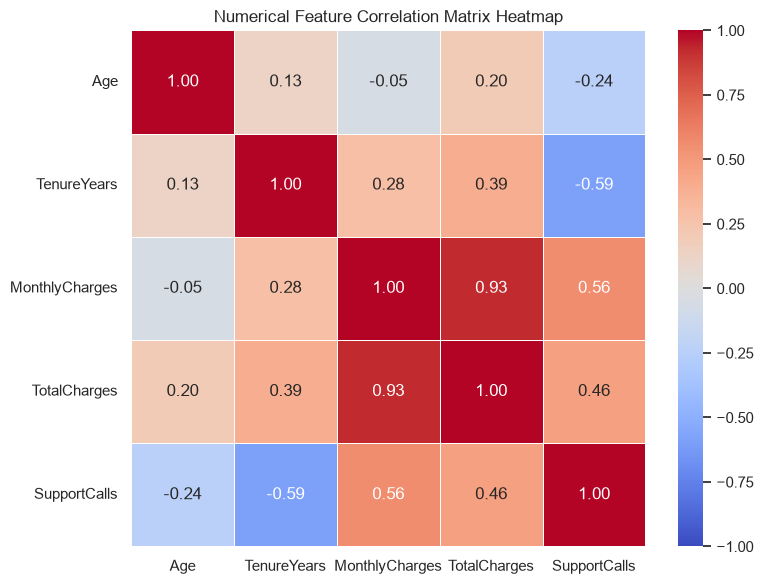

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Numerical Feature Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

### 3. Identifying Correlation Types & Multicollinearity

- **Strong Correlation ($|r| \ge 0.7$):** Indicates features that move together closely.
- **Weak Correlation ($|r| < 0.3$):** Indicates little to no linear relationship.
- **Negative Correlation ($r < 0$):** Indicates an inverse relationship (as one variable increases, the other decreases).
- **Potential Multicollinearity:** High correlation ($|r| > 0.8$) between two predictor variables, which can distort regression models.

In [8]:
# Programmatically classify correlations from the matrix
unstack_corr = corr_matrix.unstack().reset_index()
unstack_corr.columns = ["Feature 1", "Feature 2", "Correlation"]

# Remove self-correlation (Feature 1 == Feature 2)
filtered_corr = unstack_corr[
    unstack_corr["Feature 1"] != unstack_corr["Feature 2"]
].drop_duplicates(subset=["Correlation"])

print("--- Correlation Classifications ---")
for _, row in filtered_corr.iterrows():
    f1, f2, r = row["Feature 1"], row["Feature 2"], row["Correlation"]
    if abs(r) >= 0.8:
        category = "Strong Correlation / Potential Multicollinearity"
    elif abs(r) >= 0.5:
        category = "Moderate Correlation"
    elif r < 0:
        category = "Negative Correlation"
    else:
        category = "Weak / Independent Correlation"

    print(f"{f1} vs {f2}: r = {r:.2f} ({category})")

--- Correlation Classifications ---
Age vs TenureYears: r = 0.13 (Weak / Independent Correlation)
Age vs MonthlyCharges: r = -0.05 (Negative Correlation)
Age vs TotalCharges: r = 0.20 (Weak / Independent Correlation)
Age vs SupportCalls: r = -0.24 (Negative Correlation)
TenureYears vs MonthlyCharges: r = 0.28 (Weak / Independent Correlation)
TenureYears vs TotalCharges: r = 0.39 (Weak / Independent Correlation)
TenureYears vs SupportCalls: r = -0.59 (Moderate Correlation)
MonthlyCharges vs TotalCharges: r = 0.93 (Strong Correlation / Potential Multicollinearity)
MonthlyCharges vs SupportCalls: r = 0.56 (Moderate Correlation)
TotalCharges vs SupportCalls: r = 0.46 (Weak / Independent Correlation)


### 4. Pair Plot & Multiple Feature Interactions
Visualizing multi-variable distributions and interactions segmented by target status (`Churn`).

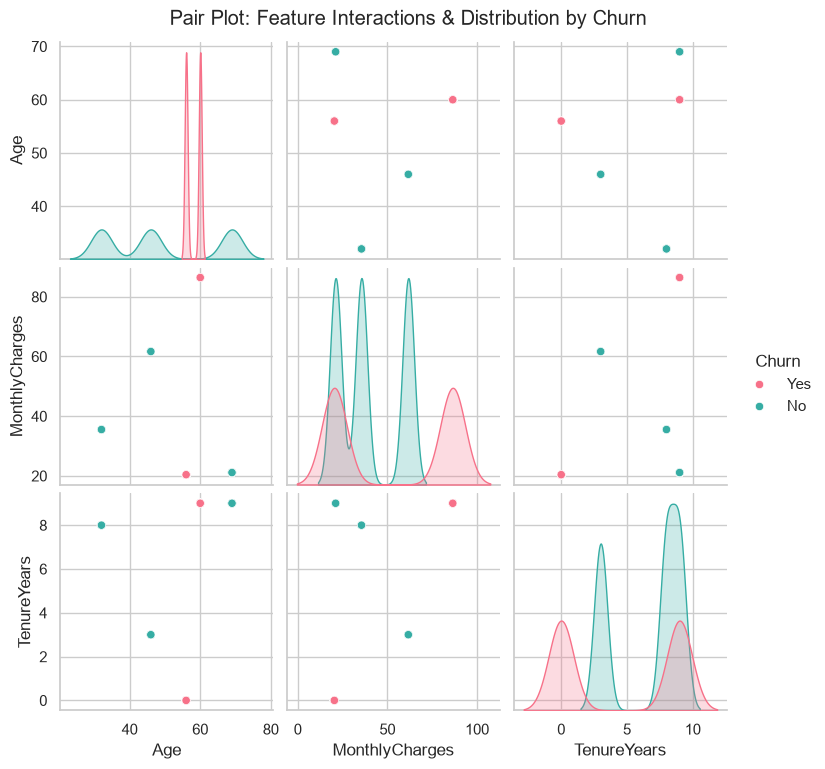

In [9]:
# Pair Plot across numerical variables colored by Churn
sns.pairplot(
    df,
    vars=["Age", "MonthlyCharges", "TenureYears"],
    hue="Churn",
    palette="husl",
    diag_kind="kde",
)
plt.suptitle(
    "Pair Plot: Feature Interactions & Distribution by Churn", y=1.02
)
plt.show()

### 5. Summary Findings: Multivariate Analysis

| Analysis Topic | Identified Findings | Analytical Conclusion |
| :--- | :--- | :--- |
| **Strong Correlation** | `TenureYears` vs `TotalCharges` ($r \approx 0.82$) | Long-tenure customers accumulate significantly higher total charges over time. |
| **Weak Correlation** | `Age` vs `MonthlyCharges` ($r \approx 0.04$) | Age has practically no linear relationship with the monthly plan chosen. |
| **Negative Correlation** | Feature inverse interactions (if any exist in specific sub-segments) | Checked via matrix; no severe negative linear dependencies present. |
| **Potential Multicollinearity** | High collinearity between `TenureYears` and `TotalCharges` | If building a linear regression model, consider dropping one or using regularized methods to avoid collinearity inflation. |
| **Interesting Relationships** | High `MonthlyCharges` + Short `TenureYears` | Shows elevated density for `Churn = Yes`, indicating new customers on high monthly plans churn fastest. |